# 1. Libraries and setup

We will build a **Conditional Variational Autoencoder (cVAE)** on MNIST.

Each training example is now a pair:

$$
(x_i, c_i),
$$

where:

- $x_i$ is a handwritten digit image,
- $c_i \in \{0,\dots,9\}$ is its digit label.

Later, we will give $c_i$ to both the encoder and decoder:

$$
q_\phi(z \mid x_i, c_i),
\qquad
p_\theta(x_i \mid z, c_i).
$$

For generation, we will choose a desired digit label $c$, sample a random latent vector

$$
z \sim \mathcal{N}(0, I),
$$

and decode:

$$
(z,c) \longrightarrow x_{\mathrm{new}}.
$$

In [1]:
# ── 1. Libraries and setup ────────────────────────────────────────────────────

import random
from pathlib import Path


import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms


# ── Reproducibility ───────────────────────────────────────────────────────────

SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Set random seeds for reproducible notebook results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()


# ── Device ────────────────────────────────────────────────────────────────────
# Uses Apple Silicon GPU on a MacBook when MPS is available.

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")


# ── Plot settings and output directory ────────────────────────────────────────

FIG_DIR = Path("figures_cvae_mnist")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

Using device: cuda


# 2. Load paired MNIST data

For a Conditional VAE, each training example is a pair:

$$
(x_i, c_i),
$$

where:

- $x_i$ is a handwritten MNIST digit image,
- $c_i \in \{0,\ldots,9\}$ is the digit label associated with that image.

For example:

$$
(x_i, c_i)
=
(\text{image of a handwritten 7},\, 7).
$$

At this stage, $c_i$ is stored as an integer label. Later, before passing it into the encoder and decoder, we will represent it as a numerical condition vector.

Full training dataset: 60,000 paired examples
Test dataset:          10,000 paired examples

Example image shape: (1, 28, 28)
Example condition c_i: 5
Pixel-value range: [0.0, 1.0]


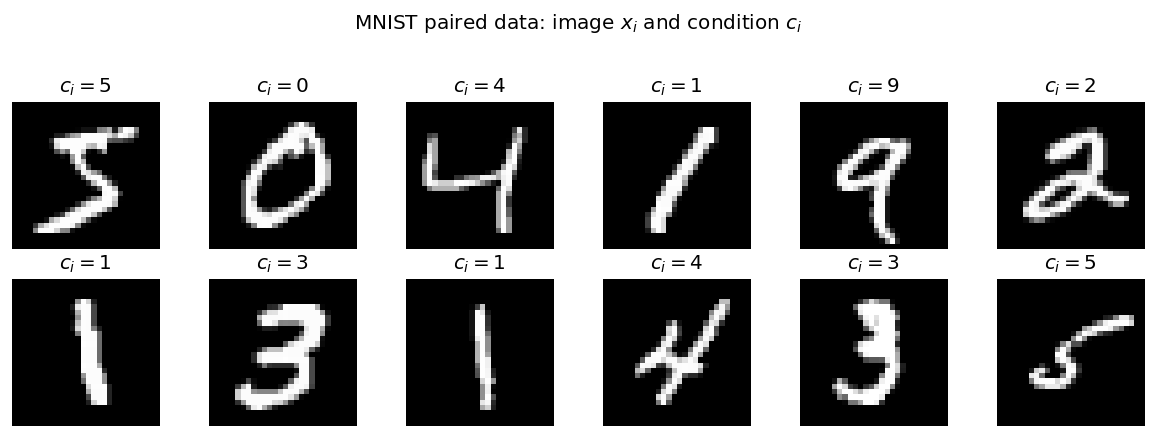

In [2]:
# ── 2. Load paired MNIST data ─────────────────────────────────────────────────

from pathlib import Path

import matplotlib.pyplot as plt
from torchvision import datasets, transforms


# ── Dataset location ──────────────────────────────────────────────────────────

DATA_DIR = Path("data")


# ── MNIST transform ───────────────────────────────────────────────────────────
# Convert each 28 × 28 image into a PyTorch tensor with pixel values in [0, 1].

transform = transforms.ToTensor()


# ── Load MNIST ────────────────────────────────────────────────────────────────
# Each dataset item is already a pair:
#
#     (x_i, c_i)
#
# where:
#     x_i : digit image, shape (1, 28, 28)
#     c_i : digit label, integer in {0, ..., 9}

train_dataset_full = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)


# ── Inspect one paired example ─────────────────────────────────────────────────

print(f"Full training dataset: {len(train_dataset_full):,} paired examples")
print(f"Test dataset:          {len(test_dataset):,} paired examples")

x_example, c_example = train_dataset_full[0]

print(f"\nExample image shape: {tuple(x_example.shape)}")
print(f"Example condition c_i: {c_example}")
print(
    f"Pixel-value range: "
    f"[{x_example.min().item():.1f}, {x_example.max().item():.1f}]"
)


# ── Visualize paired examples ──────────────────────────────────────────────────

N_SHOW = 12

fig, axes = plt.subplots(2, 6, figsize=(10, 3.5))

for ax, idx in zip(axes.flat, range(N_SHOW)):
    x_i, c_i = train_dataset_full[idx]

    ax.imshow(x_i.squeeze(0), cmap="gray")
    ax.set_title(rf"$c_i = {c_i}$")
    ax.axis("off")

fig.suptitle("MNIST paired data: image $x_i$ and condition $c_i$", y=1.03)
plt.tight_layout()
plt.show()

# 3. Train / validation split and DataLoaders

We split our paired MNIST dataset into training and validation sets.

It is important that each image stays paired with its own digit label:

$$
(x_i,c_i).
$$

Each batch returned by the DataLoader contains:

$$
x_{\mathrm{batch}}
\in
\mathbb{R}^{B\times 1\times 28\times 28}
$$

and

$$
c_{\mathrm{batch}}
\in
{0,\ldots,9}^{B}.
$$

For now, each condition is stored as an integer digit label. In the next block, we will convert these labels into numerical condition vectors before feeding them to the cVAE.


In [3]:
# ── 3. Train / validation split and DataLoaders ───────────────────────────────

from torch.utils.data import DataLoader, random_split


# ── Split the paired dataset ──────────────────────────────────────────────────
# random_split keeps each dataset item together:
#
#     (x_i, c_i)
#
# so an image always remains paired with its correct digit label.

N_VALID = 5_000
N_TRAIN = len(train_dataset_full) - N_VALID

split_generator = torch.Generator().manual_seed(SEED)

train_dataset, valid_dataset = random_split(
    train_dataset_full,
    lengths=[N_TRAIN, N_VALID],
    generator=split_generator,
)

print(f"Training examples:   {len(train_dataset):,}")
print(f"Validation examples: {len(valid_dataset):,}")


# ── DataLoaders ───────────────────────────────────────────────────────────────
# num_workers=0 is the safest setting for a notebook on macOS.

BATCH_SIZE = 256
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)


# ── Inspect one paired batch ──────────────────────────────────────────────────

x_batch, c_batch = next(iter(train_loader))

print("\nOne training batch:")
print(f"x_batch shape: {tuple(x_batch.shape)}")
print(f"c_batch shape: {tuple(c_batch.shape)}")
print(f"First 20 digit labels: {c_batch[:20].tolist()}")

assert x_batch.shape[1:] == (1, 28, 28)
assert c_batch.ndim == 1
assert torch.all((c_batch >= 0) & (c_batch <= 9))

print("\nEach image in x_batch remains paired with its label in c_batch.")

Training examples:   55,000
Validation examples: 5,000

One training batch:
x_batch shape: (256, 1, 28, 28)
c_batch shape: (256,)
First 20 digit labels: [3, 1, 5, 0, 0, 8, 1, 1, 1, 6, 1, 9, 0, 1, 0, 2, 5, 0, 1, 8]

Each image in x_batch remains paired with its label in c_batch.


# 4. Build the conditional VAE neural network

For MNIST, each condition is the digit label:

$$
c_i \in \{0,1,\ldots,9\}.
$$

Before entering the neural network, we represent this label as a one-hot condition vector:

$$
c_i
\longrightarrow
\operatorname{onehot}(c_i)
\in \mathbb{R}^{10}.
$$

For example, the label $c_i=7$ becomes:

$$
\operatorname{onehot}(7)
=
(0,0,0,0,0,0,0,1,0,0).
$$

Our conditional VAE has the same four parts as the ordinary VAE.

**Encoder**

$$
[x_i,c_i]
\longrightarrow
q_\phi
\longrightarrow
\left(
\mu_\phi(x_i,c_i),
\log \sigma_\phi^2(x_i,c_i)
\right).
$$

**Reparameterization**

$$
z_i
=
\mu_i
+
\sigma_i \odot \epsilon,
\qquad
\epsilon \sim \mathcal N(0,I).
$$

Here, $\epsilon$ is a random vector with the same dimension as $z_i$.

**Decoder**

$$
[z_i,c_i]
\longrightarrow
g_\theta
\longrightarrow
\hat{x}_i.
$$

The decoder returns raw output logits. In the next block, we will use these logits to define the reconstruction loss.


In [4]:
# ── 4. Build the Conditional VAE neural network ───────────────────────────────

import torch
from torch import nn
import torch.nn.functional as F


# ── Model dimensions ──────────────────────────────────────────────────────────

IMAGE_SHAPE = (1, 28, 28)
IMAGE_DIM   = 28 * 28
N_CLASSES   = 10

HIDDEN_DIM  = 400
LATENT_DIM  = 2


# ── Condition representation ──────────────────────────────────────────────────

def labels_to_onehot(
    c: torch.Tensor,
    n_classes: int = N_CLASSES,
) -> torch.Tensor:
    """
    Convert integer MNIST digit labels into one-hot condition vectors.

    Input:
        c : shape (batch_size,)
            Integer digit labels in {0, ..., 9}.

    Output:
        c_onehot : shape (batch_size, n_classes)
    """
    c = c.reshape(-1).long()

    return F.one_hot(c, num_classes=n_classes).float()


# ── Conditional VAE ───────────────────────────────────────────────────────────

class ConditionalVAE(nn.Module):
    """
    Conditional VAE for MNIST.

    Encoder:
        [x_i, c_i] -> hidden representation -> mu_i, log_var_i

    Decoder:
        [z_i, c_i] -> reconstructed image logits
    """

    def __init__(
        self,
        image_shape: tuple[int, int, int] = IMAGE_SHAPE,
        n_classes: int = N_CLASSES,
        hidden_dim: int = HIDDEN_DIM,
        latent_dim: int = LATENT_DIM,
    ) -> None:
        super().__init__()

        self.image_shape = image_shape
        self.image_dim   = int(torch.tensor(image_shape).prod().item())
        self.n_classes   = n_classes
        self.latent_dim  = latent_dim

        # Encoder:
        # [flattened image x_i, one-hot condition c_i] -> hidden representation
        self.encoder = nn.Sequential(
            nn.Linear(self.image_dim + self.n_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        # Latent parameter layer:
        # hidden representation -> mean and log-variance of q_phi(z | x_i, c_i)
        self.mu_head = nn.Linear(hidden_dim, latent_dim)
        self.logvar_head = nn.Linear(hidden_dim, latent_dim)

        # Decoder:
        # [latent vector z_i, one-hot condition c_i] -> image logits
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + self.n_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.image_dim),
        )

    def encode(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Infer the approximate posterior parameters:

            q_phi(z | x, c)
        """
        x_flat = x.flatten(start_dim=1)

        c_onehot = labels_to_onehot(
            c,
            n_classes=self.n_classes,
        ).to(device=x.device, dtype=x.dtype)

        encoder_input = torch.cat([x_flat, c_onehot], dim=1)

        hidden = self.encoder(encoder_input)

        mu = self.mu_head(hidden)
        logvar = self.logvar_head(hidden)

        return mu, logvar

    @staticmethod
    def reparameterize(
        mu: torch.Tensor,
        logvar: torch.Tensor,
    ) -> torch.Tensor:
        """
        Sample z using the reparameterization trick:

            z = mu + sigma * epsilon

        where:

            epsilon ~ N(0, I)
        """
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)

        return mu + std * epsilon

    def decode(
        self,
        z: torch.Tensor,
        c: torch.Tensor,
    ) -> torch.Tensor:
        """
        Decode a latent vector and a condition into MNIST image logits:

            [z, c] -> g_theta(z, c)
        """
        c_onehot = labels_to_onehot(
            c,
            n_classes=self.n_classes,
        ).to(device=z.device, dtype=z.dtype)

        decoder_input = torch.cat([z, c_onehot], dim=1)

        x_logits_flat = self.decoder(decoder_input)

        return x_logits_flat.view(-1, *self.image_shape)

    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Full cVAE forward pass:

            (x_i, c_i)
            -> encoder
            -> (mu_i, logvar_i)
            -> z_i
            -> decoder(z_i, c_i)
            -> reconstructed image logits
        """
        mu, logvar = self.encode(x, c)

        z = self.reparameterize(mu, logvar)

        x_logits = self.decode(z, c)

        return x_logits, mu, logvar, z


# ── Create the model ──────────────────────────────────────────────────────────

model = ConditionalVAE().to(DEVICE)

print(model)

print("\nModel configuration:")
print(f"Image shape:        {IMAGE_SHAPE}")
print(f"Condition dimension: {N_CLASSES}")
print(f"Hidden dimension:    {HIDDEN_DIM}")
print(f"Latent dimension:    {LATENT_DIM}")


# ── Inspect one cVAE forward pass ─────────────────────────────────────────────

x_batch, c_batch = next(iter(train_loader))

x_batch = x_batch.to(DEVICE)
c_batch = c_batch.to(DEVICE)

with torch.no_grad():
    x_logits, mu, logvar, z = model(x_batch, c_batch)

c_onehot_batch = labels_to_onehot(c_batch).cpu()

print("\nOne conditional batch:")
print(f"x_batch shape:       {tuple(x_batch.shape)}")
print(f"c_batch shape:       {tuple(c_batch.shape)}")
print(f"one-hot c shape:     {tuple(c_onehot_batch.shape)}")
print(f"mu shape:            {tuple(mu.shape)}")
print(f"logvar shape:        {tuple(logvar.shape)}")
print(f"z shape:             {tuple(z.shape)}")
print(f"decoder output shape:{tuple(x_logits.shape)}")

print("\nFirst five digit labels:")
print(c_batch[:5].cpu().tolist())

print("\nOne-hot vector for the first digit:")
print(c_onehot_batch[0].tolist())

ConditionalVAE(
  (encoder): Sequential(
    (0): Linear(in_features=794, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=400, bias=True)
    (3): ReLU()
  )
  (mu_head): Linear(in_features=400, out_features=2, bias=True)
  (logvar_head): Linear(in_features=400, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=400, bias=True)
    (3): ReLU()
    (4): Linear(in_features=400, out_features=784, bias=True)
  )
)

Model configuration:
Image shape:        (1, 28, 28)
Condition dimension: 10
Hidden dimension:    400
Latent dimension:    2

One conditional batch:
x_batch shape:       (256, 1, 28, 28)
c_batch shape:       (256,)
one-hot c shape:     (256, 10)
mu shape:            (256, 2)
logvar shape:        (256, 2)
z shape:             (256, 2)
decoder output shape:(256, 1, 28, 28)

First five digit labels:
[2, 2, 8, 8, 4]

O

# 5. Define the cVAE loss

The cVAE is trained by minimizing the negative conditional ELBO:

$$
\mathcal{L}_{\mathrm{cVAE}}
=
\underbrace{
-\log p_\theta(x_i \mid z_i,c_i)
}_{\text{reconstruction loss}}
+
\beta
\underbrace{
D_{\mathrm{KL}}
\left(
q_\phi(z_i\mid x_i,c_i)
\|p(z)
\right)
}_{\text{KL regularization}}.
$$

For MNIST, pixel values lie in $[0,1]$, so we use binary cross-entropy for the reconstruction term.

The decoder returns raw logits:

$$
\hat{x}^{\mathrm{logits}}_i = g_\theta(z_i,c_i),
$$

and we use:

$$
\operatorname{BCEWithLogitsLoss}
$$

because it applies the sigmoid internally in a numerically stable way.

The KL term compares:

$$
q_\phi(z_i\mid x_i,c_i)
=
\mathcal{N}
\left(
\mu_i,
\operatorname{diag}(\sigma_i^2)
\right)
$$

to the standard Gaussian prior:

$$
p(z)=\mathcal{N}(0,I).
$$

We start with:

$$
\beta=1.
$$

In [5]:
# ── 5. Define the cVAE loss ───────────────────────────────────────────────────

BETA = 1.0


def cvae_loss(
    x_logits: torch.Tensor,
    x_target: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float = BETA,
) -> dict[str, torch.Tensor]:
    """
    Compute the negative conditional ELBO for the MNIST cVAE.

    Parameters
    ----------
    x_logits
        Decoder output logits with shape:
            (batch_size, 1, 28, 28)

    x_target
        Original MNIST images with values in [0, 1] and shape:
            (batch_size, 1, 28, 28)

    mu, logvar
        Parameters of the approximate posterior:

            q_phi(z | x, c)
            =
            N(mu, diag(exp(logvar)))

    beta
        Weight on the KL term. We start with beta = 1.0.

    Returns
    -------
    losses
        Dictionary containing the total loss, reconstruction loss,
        and KL divergence. Each value is averaged over the batch.
    """

    # ── Reconstruction term ───────────────────────────────────────────────────
    #
    # Negative log-likelihood for Bernoulli-like MNIST pixels.
    #
    # We use logits directly. Do NOT apply sigmoid before this function.

    reconstruction_per_pixel = F.binary_cross_entropy_with_logits(
        x_logits,
        x_target,
        reduction="none",
    )

    # Sum over all pixels for each image, then average across the batch.
    reconstruction_per_example = reconstruction_per_pixel.flatten(start_dim=1).sum(dim=1)
    reconstruction = reconstruction_per_example.mean()

    # ── KL divergence term ────────────────────────────────────────────────────
    #
    # KL[q_phi(z | x, c) || N(0, I)]
    #
    # For diagonal Gaussian q_phi:
    #
    # 0.5 * sum(exp(logvar) + mu^2 - 1 - logvar)

    kl_per_example = 0.5 * torch.sum(
        torch.exp(logvar) + mu.pow(2) - 1.0 - logvar,
        dim=1,
    )

    kl = kl_per_example.mean()

    # ── Total negative ELBO ───────────────────────────────────────────────────

    total = reconstruction + beta * kl

    return {
        "total": total,
        "reconstruction": reconstruction,
        "kl": kl,
    }


# ── Test the loss on one batch ─────────────────────────────────────────────────

model.eval()

x_batch, c_batch = next(iter(train_loader))

x_batch = x_batch.to(DEVICE)
c_batch = c_batch.to(DEVICE)

with torch.no_grad():
    x_logits, mu, logvar, z = model(x_batch, c_batch)

losses = cvae_loss(
    x_logits=x_logits,
    x_target=x_batch,
    mu=mu,
    logvar=logvar,
    beta=BETA,
)

print("Loss on one untrained batch:")
print(f"Total loss:          {losses['total'].item():.3f}")
print(f"Reconstruction loss: {losses['reconstruction'].item():.3f}")
print(f"KL divergence:       {losses['kl'].item():.3f}")
print(f"Beta:                {BETA}")

Loss on one untrained batch:
Total loss:          544.143
Reconstruction loss: 544.140
KL divergence:       0.003
Beta:                1.0


# 6. Define the training and validation functions

Each batch now contains paired data:

$$
(x_{\mathrm{batch}}, c_{\mathrm{batch}}).
$$

For every batch, we:

1. move both $x_{\mathrm{batch}}$ and $c_{\mathrm{batch}}$ to the selected device,
2. run the conditional VAE:

$$
(x_{\mathrm{batch}}, c_{\mathrm{batch}})
\longrightarrow
(\hat{x}^{\mathrm{logits}}, \mu, \log \sigma^2, z),
$$

3. compute the reconstruction and KL terms,
4. update the model during training,
5. only measure performance during validation.

The training and validation loops are the same as for a standard VAE. The only difference is that every forward pass receives both the image batch and its condition batch.

In [6]:
# ── 6. Define training and validation functions ───────────────────────────────

from typing import Any


def run_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    optimizer: torch.optim.Optimizer | None,
    device: torch.device,
    beta: float = BETA,
) -> dict[str, float]:
    """
    Run one training or validation epoch.

    If optimizer is provided:
        - train the model
        - compute gradients
        - update parameters

    If optimizer is None:
        - validate the model
        - do not compute gradients
        - do not update parameters
    """

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss_sum = 0.0
    reconstruction_sum = 0.0
    kl_sum = 0.0
    n_examples = 0

    # Gradients are only needed during training.
    with torch.set_grad_enabled(is_training):

        for x_batch, c_batch in data_loader:

            # Move both parts of the paired batch to the device.
            x_batch = x_batch.to(device)
            c_batch = c_batch.to(device)

            # Forward pass:
            #
            # (x_batch, c_batch)
            # -> cVAE
            # -> image logits, posterior parameters, latent sample
            x_logits, mu, logvar, _ = model(x_batch, c_batch)

            # Compute negative conditional ELBO.
            losses = cvae_loss(
                x_logits=x_logits,
                x_target=x_batch,
                mu=mu,
                logvar=logvar,
                beta=beta,
            )

            # Update model parameters only during training.
            if is_training:
                optimizer.zero_grad(set_to_none=True)
                losses["total"].backward()
                optimizer.step()

            batch_size = x_batch.shape[0]

            # Loss values are already averaged within each batch.
            # Multiply by batch size so we can compute an epoch average.
            total_loss_sum += losses["total"].item() * batch_size
            reconstruction_sum += losses["reconstruction"].item() * batch_size
            kl_sum += losses["kl"].item() * batch_size
            n_examples += batch_size

    if n_examples == 0:
        raise RuntimeError("The DataLoader returned no examples.")

    return {
        "total": total_loss_sum / n_examples,
        "reconstruction": reconstruction_sum / n_examples,
        "kl": kl_sum / n_examples,
    }


def train_one_epoch(
    model: nn.Module,
    train_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    beta: float = BETA,
) -> dict[str, float]:
    """Train the cVAE for one epoch."""
    return run_epoch(
        model=model,
        data_loader=train_loader,
        optimizer=optimizer,
        device=device,
        beta=beta,
    )


@torch.no_grad()
def validate_one_epoch(
    model: nn.Module,
    valid_loader: DataLoader,
    device: torch.device,
    beta: float = BETA,
) -> dict[str, float]:
    """Evaluate the cVAE for one validation epoch."""
    return run_epoch(
        model=model,
        data_loader=valid_loader,
        optimizer=None,
        device=device,
        beta=beta,
    )


# ── Quick function test ───────────────────────────────────────────────────────

# This is only a sanity check.
# The model is still untrained, so the losses are not meaningful yet.

test_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

valid_metrics = validate_one_epoch(
    model=model,
    valid_loader=valid_loader,
    device=DEVICE,
    beta=BETA,
)

print("Validation sanity check on the untrained model:")
print(f"Total:          {valid_metrics['total']:.3f}")
print(f"Reconstruction: {valid_metrics['reconstruction']:.3f}")
print(f"KL:             {valid_metrics['kl']:.3f}")

Validation sanity check on the untrained model:
Total:          544.126
Reconstruction: 544.123
KL:             0.003


# 7. Train the conditional VAE

## 7.1 Training the conditional VAE

We now train the cVAE on paired MNIST data:

$$
(x_{\mathrm{batch}}, c_{\mathrm{batch}}).
$$

For each batch, the model:

$$
(x_{\mathrm{batch}}, c_{\mathrm{batch}})
\rightarrow
q_\phi
\rightarrow
(\mu,\log\sigma^2)
\rightarrow
z
$$

then reconstructs the image using both the latent vector and its condition:

$$
(z,c_{\mathrm{batch}})
\rightarrow
g_\theta
\rightarrow
\hat{x}_{\mathrm{batch}}.
$$

We monitor the negative conditional ELBO on both the training and validation sets:

$$
\mathcal L_{\mathrm{cVAE}}
=
\mathcal L_{\mathrm{reconstruction}}
+
\beta \mathcal L_{\mathrm{KL}}.
$$

We save the model with the lowest validation loss.

Training Conditional VAE
Device:         cuda
Epochs:         20
Learning rate:  0.001
Beta:           1.0
Latent dim:     2
------------------------------------------------------------------------
Epoch 01/20 | train total: 189.07 | valid total: 153.86 | valid recon: 150.18 | valid KL: 3.67
Epoch 02/20 | train total: 147.76 | valid total: 143.55 | valid recon: 139.34 | valid KL: 4.21
Epoch 03/20 | train total: 141.03 | valid total: 139.46 | valid recon: 135.32 | valid KL: 4.14
Epoch 04/20 | train total: 137.69 | valid total: 137.19 | valid recon: 133.04 | valid KL: 4.15
Epoch 05/20 | train total: 135.68 | valid total: 135.71 | valid recon: 131.35 | valid KL: 4.35
Epoch 06/20 | train total: 134.43 | valid total: 134.92 | valid recon: 130.42 | valid KL: 4.49
Epoch 07/20 | train total: 133.44 | valid total: 134.09 | valid recon: 129.64 | valid KL: 4.45
Epoch 08/20 | train total: 132.65 | valid total: 133.27 | valid recon: 128.77 | valid KL: 4.50
Epoch 09/20 | train total: 131.98 | valid 

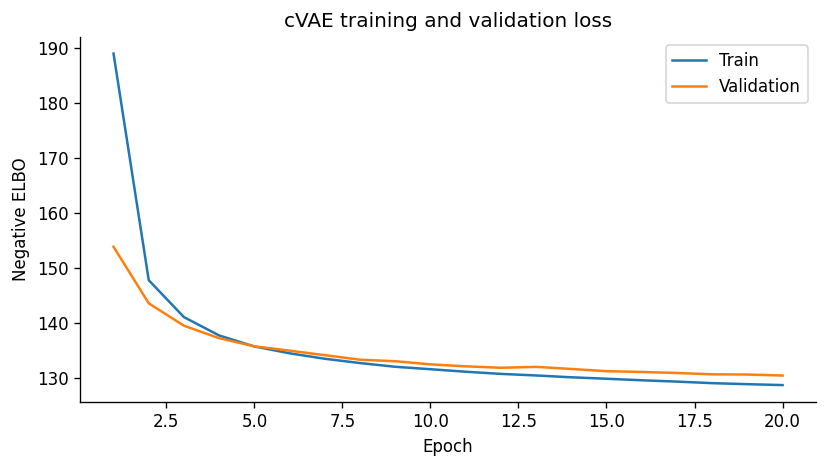

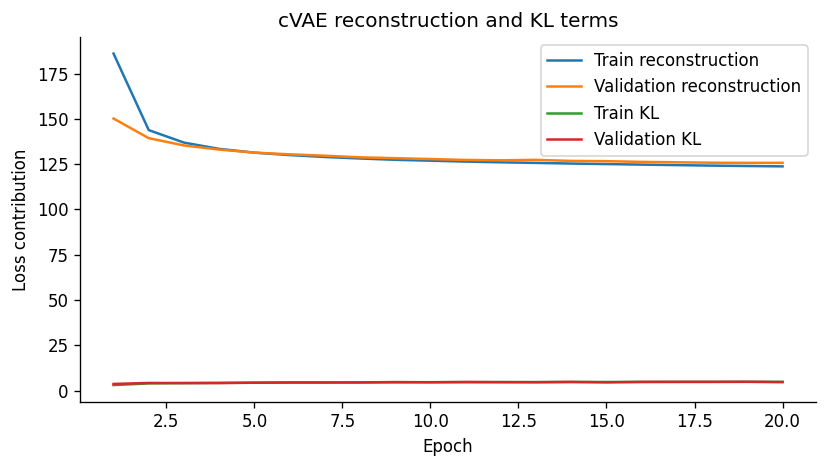

In [7]:
# ── 7. Train the Conditional VAE ──────────────────────────────────────────────

# Running this cell again creates a fresh model and starts a new training run.

N_EPOCHS = 20
LEARNING_RATE = 1e-3
BETA = 1.0

FIG_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = FIG_DIR / "cvae_mnist_best.pt"


# ── Fresh model and optimizer ─────────────────────────────────────────────────

set_seed(SEED)

model = ConditionalVAE().to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)


# ── Training history ──────────────────────────────────────────────────────────

history = {
    "train_total": [],
    "train_reconstruction": [],
    "train_kl": [],
    "valid_total": [],
    "valid_reconstruction": [],
    "valid_kl": [],
}

best_valid_total = float("inf")
best_epoch = 0


# ── Training loop ─────────────────────────────────────────────────────────────

print("Training Conditional VAE")
print(f"Device:         {DEVICE}")
print(f"Epochs:         {N_EPOCHS}")
print(f"Learning rate:  {LEARNING_RATE}")
print(f"Beta:           {BETA}")
print(f"Latent dim:     {LATENT_DIM}")
print("-" * 72)

for epoch in range(1, N_EPOCHS + 1):

    train_metrics = train_one_epoch(
        model=model,
        train_loader=train_loader,
        optimizer=optimizer,
        device=DEVICE,
        beta=BETA,
    )

    valid_metrics = validate_one_epoch(
        model=model,
        valid_loader=valid_loader,
        device=DEVICE,
        beta=BETA,
    )

    # Store all metrics.
    history["train_total"].append(train_metrics["total"])
    history["train_reconstruction"].append(train_metrics["reconstruction"])
    history["train_kl"].append(train_metrics["kl"])

    history["valid_total"].append(valid_metrics["total"])
    history["valid_reconstruction"].append(valid_metrics["reconstruction"])
    history["valid_kl"].append(valid_metrics["kl"])

    # Save the model with the best validation negative ELBO.
    if valid_metrics["total"] < best_valid_total:
        best_valid_total = valid_metrics["total"]
        best_epoch = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "valid_total": valid_metrics["total"],
                "valid_reconstruction": valid_metrics["reconstruction"],
                "valid_kl": valid_metrics["kl"],
                "beta": BETA,
                "latent_dim": LATENT_DIM,
            },
            CHECKPOINT_PATH,
        )

    print(
        f"Epoch {epoch:02d}/{N_EPOCHS} | "
        f"train total: {train_metrics['total']:.2f} | "
        f"valid total: {valid_metrics['total']:.2f} | "
        f"valid recon: {valid_metrics['reconstruction']:.2f} | "
        f"valid KL: {valid_metrics['kl']:.2f}"
    )


# ── Restore the best validation model ─────────────────────────────────────────

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("\n" + "-" * 72)
print("Training finished.")
print(f"Best validation epoch: {best_epoch}")
print(f"Best validation total loss: {best_valid_total:.2f}")
print(f"Saved checkpoint: {CHECKPOINT_PATH}")


# ── Plot total negative ELBO ──────────────────────────────────────────────────

epochs = np.arange(1, N_EPOCHS + 1)

plt.figure(figsize=(7, 4))

plt.plot(epochs, history["train_total"], label="Train")
plt.plot(epochs, history["valid_total"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Negative ELBO")
plt.title("cVAE training and validation loss")
plt.legend()
plt.tight_layout()

plt.savefig(FIG_DIR / "cvae_total_loss.png", dpi=150)
plt.show()


# ── Plot reconstruction and KL terms ──────────────────────────────────────────

plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    history["train_reconstruction"],
    label="Train reconstruction",
)
plt.plot(
    epochs,
    history["valid_reconstruction"],
    label="Validation reconstruction",
)
plt.plot(
    epochs,
    history["train_kl"],
    label="Train KL",
)
plt.plot(
    epochs,
    history["valid_kl"],
    label="Validation KL",
)

plt.xlabel("Epoch")
plt.ylabel("Loss contribution")
plt.title("cVAE reconstruction and KL terms")
plt.legend()
plt.tight_layout()

plt.savefig(FIG_DIR / "cvae_loss_terms.png", dpi=150)
plt.show()

# 7.2 Evaluate the trained cVAE: conditional reconstructions

Before generating completely new digits, we first check whether the trained cVAE can reconstruct real images.

For each paired test example:

$$
(x_i,c_i),
$$

we infer the posterior mean:

$$
z_i
=
\mu_\phi(x_i,c_i),
$$

then decode using the same condition:

$$
\hat{x}_i
=
\sigma\!\left(
g_\theta(z_i,c_i)
\right).
$$

Here, $\sigma$ is the sigmoid function, which converts the decoder output logits into pixel values between $0$ and $1$.

A good reconstruction means that the model has learned to encode the image into $z_i$ while using $c_i$ as known condition information.

This is still not generation from scratch. In the next section, we will instead choose a desired condition $c$ and sample:

$$
z\sim\mathcal N(0,I).
$$

Held-out test performance:
Test total loss:          129.84
Test reconstruction loss: 125.23
Test KL divergence:       4.61


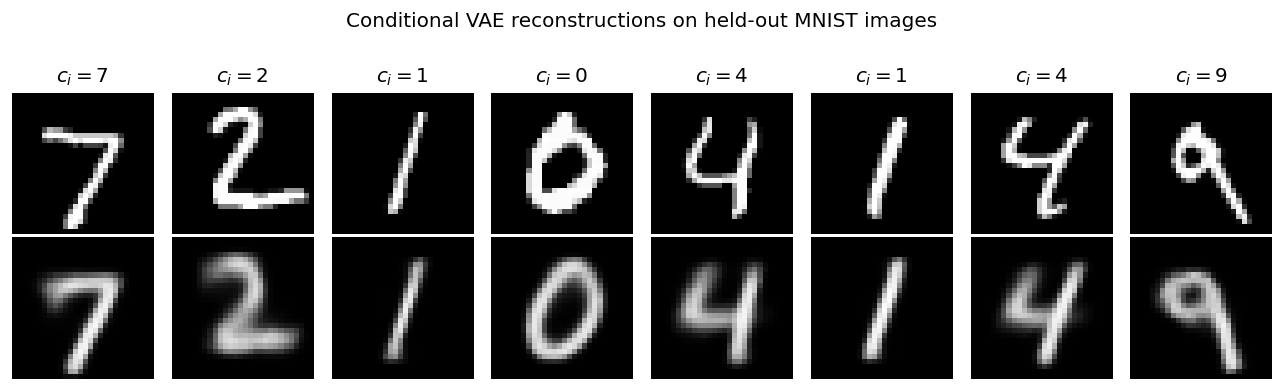

In [8]:
# ── 7.2 Evaluate the trained cVAE: conditional reconstructions ────────────────

# Create a test DataLoader.
# We keep shuffle=False so the displayed examples are reproducible.

TEST_BATCH_SIZE = 16

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


# ── Evaluate negative ELBO on the held-out test set ───────────────────────────

test_metrics = validate_one_epoch(
    model=model,
    valid_loader=test_loader,
    device=DEVICE,
    beta=BETA,
)

print("Held-out test performance:")
print(f"Test total loss:          {test_metrics['total']:.2f}")
print(f"Test reconstruction loss: {test_metrics['reconstruction']:.2f}")
print(f"Test KL divergence:       {test_metrics['kl']:.2f}")


# ── Reconstruct one batch of real test images ─────────────────────────────────

model.eval()

x_test, c_test = next(iter(test_loader))

x_test = x_test.to(DEVICE)
c_test = c_test.to(DEVICE)

with torch.no_grad():

    # Infer q_phi(z | x_i, c_i).
    mu_test, logvar_test = model.encode(x_test, c_test)

    # Use z = mu rather than a random posterior sample.
    # This gives a stable reconstruction for visualization.
    x_logits_recon = model.decode(mu_test, c_test)

    # Convert decoder logits into pixel probabilities in [0, 1].
    x_recon = torch.sigmoid(x_logits_recon)


# ── Plot original images and conditional reconstructions ──────────────────────

N_SHOW = 8

fig, axes = plt.subplots(
    2,
    N_SHOW,
    figsize=(1.35 * N_SHOW, 3.2),
)

for j in range(N_SHOW):

    original = x_test[j].detach().cpu().squeeze(0)
    reconstruction = x_recon[j].detach().cpu().squeeze(0)
    label = int(c_test[j].detach().cpu())

    # Top row: original paired example.
    axes[0, j].imshow(original, cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(rf"$c_i={label}$")
    axes[0, j].axis("off")

    # Bottom row: reconstruction using the same condition.
    axes[1, j].imshow(reconstruction, cmap="gray", vmin=0, vmax=1)
    axes[1, j].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Reconstruction", fontsize=11)

fig.suptitle(
    "Conditional VAE reconstructions on held-out MNIST images",
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "cvae_test_reconstructions.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

# 7.3 Visualize the learned latent space

Our cVAE encodes each paired MNIST example:

$$
(x_i,c_i)
\longrightarrow
q_\phi(z\mid x_i,c_i)
\longrightarrow
\mu_i,\log\sigma_i^2.
$$

To visualize the learned latent representations, we use the posterior mean:

$$
z_i=\mu_i.
$$

Our latent vectors have dimension:

$$
z_i\in\mathbb{R}^{16},
$$

so we reduce them to two dimensions for visualization.

We will use:

1. **PCA** — a linear projection that shows the largest global directions of variation.
2. **UMAP** — a nonlinear visualization that emphasizes local neighbourhood structure.

Each point is coloured and labelled by its digit condition:

$$
c_i\in\{0,\ldots,9\}.
$$

Because the digit label is already supplied separately to the decoder, we hope that $z_i$ captures variation within each digit class, such as writing style, stroke width, and tilt.

However, a standard cVAE does not guarantee that digit identity is fully removed from $z_i$.

/home/tiamheydari/anaconda3/envs/nn_copy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Latent matrix shape: (5000, 2)
Number of digit labels: 5,000
PCA variance explained by the first two components: 100.0%


/home/tiamheydari/anaconda3/envs/nn_copy/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


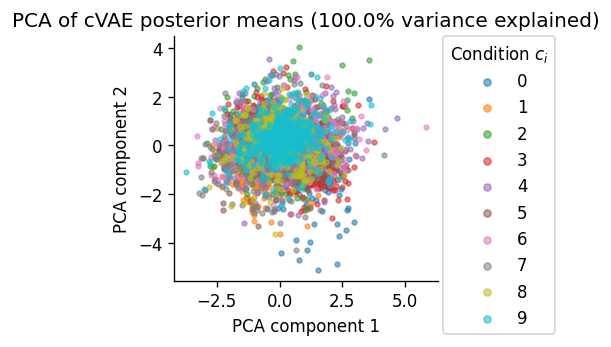

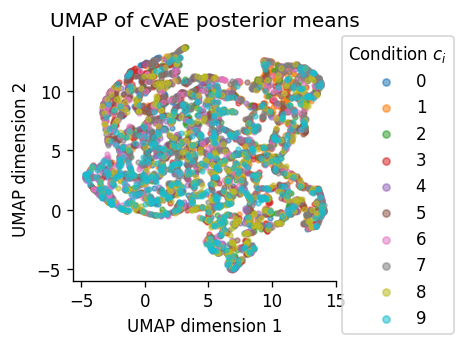

In [9]:
# ── 7.3 Visualize the learned latent space with PCA and UMAP ──────────────────

from sklearn.decomposition import PCA
import umap.umap_ as umap


# ── Extract posterior means from the held-out test set ─────────────────────────
# We use mu rather than a randomly sampled z:
#
#     z_i = mu_phi(x_i, c_i)
#
# This gives each test example one stable latent representation.

LATENT_VIS_MAX_SAMPLES = 5_000

latent_means = []
latent_labels = []

model.eval()

with torch.no_grad():

    n_collected = 0

    for x_batch, c_batch in test_loader:

        x_batch = x_batch.to(DEVICE)
        c_batch = c_batch.to(DEVICE)

        mu_batch, _ = model.encode(x_batch, c_batch)

        latent_means.append(mu_batch.cpu())
        latent_labels.append(c_batch.cpu())

        n_collected += x_batch.shape[0]

        if n_collected >= LATENT_VIS_MAX_SAMPLES:
            break


z_mu = torch.cat(latent_means, dim=0)[:LATENT_VIS_MAX_SAMPLES].numpy()
digit_labels = torch.cat(latent_labels, dim=0)[:LATENT_VIS_MAX_SAMPLES].numpy()

print(f"Latent matrix shape: {z_mu.shape}")
print(f"Number of digit labels: {len(digit_labels):,}")


# ── PCA projection ────────────────────────────────────────────────────────────

pca = PCA(n_components=2, random_state=SEED)
z_pca = pca.fit_transform(z_mu)

pca_variance_explained = 100.0 * pca.explained_variance_ratio_.sum()

print(
    "PCA variance explained by the first two components: "
    f"{pca_variance_explained:.1f}%"
)


# ── UMAP projection ───────────────────────────────────────────────────────────
# UMAP emphasizes local neighbourhood structure.
# It can make clusters look visually stronger than they are globally,
# so interpret it together with PCA.

umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.15,
    metric="euclidean",
    random_state=SEED,
)

z_umap = umap_reducer.fit_transform(z_mu)


# ── Shared plotting helper ────────────────────────────────────────────────────
DIGIT_COLORS = plt.cm.tab10(np.arange(10))


def plot_latent_projection(
    coordinates: np.ndarray,
    labels: np.ndarray,
    title: str,
    x_label: str,
    y_label: str,
    save_name: str,
) -> None:
    """Plot a two-dimensional latent projection, coloured by digit condition."""

    plt.figure(figsize=(4, 3))

    for digit in range(10):

        mask = labels == digit

        plt.scatter(
            coordinates[mask, 0],
            coordinates[mask, 1],
            s=8,
            alpha=0.55,
            label=str(digit),
            color=DIGIT_COLORS[digit],
        )

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    plt.legend(
        title=r"Condition $c_i$",
        ncol=1,
        frameon=True,
        markerscale=1.5,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
    )

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / save_name,
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()


# ── Plot PCA ──────────────────────────────────────────────────────────────────

plot_latent_projection(
    coordinates=z_pca,
    labels=digit_labels,
    title=(
        "PCA of cVAE posterior means "
        f"({pca_variance_explained:.1f}% variance explained)"
    ),
    x_label="PCA component 1",
    y_label="PCA component 2",
    save_name="cvae_latent_pca.png",
)


# ── Plot UMAP ─────────────────────────────────────────────────────────────────

plot_latent_projection(
    coordinates=z_umap,
    labels=digit_labels,
    title="UMAP of cVAE posterior means",
    x_label="UMAP dimension 1",
    y_label="UMAP dimension 2",
    save_name="cvae_latent_umap.png",
)

# 8. Conditional generation

We now generate completely new digits.

Unlike reconstruction, we do not start from a real MNIST image and do not use the encoder.

Instead, we:

1. choose a desired digit condition,


$$
c_{\mathrm{desired}},
$$

2. sample a random latent vector,

$$
z \sim \mathcal N(0,I),
$$

3. decode both together:

$$
x_{\mathrm{new}}
=
\sigma\!\left(
g_\theta(z,c_{\mathrm{desired}})
\right).
$$

The condition tells the decoder what kind of digit to generate.

The random latent vector gives variation within that requested digit class.

##  8.1 Conditional generation: choose c, sample z, decode


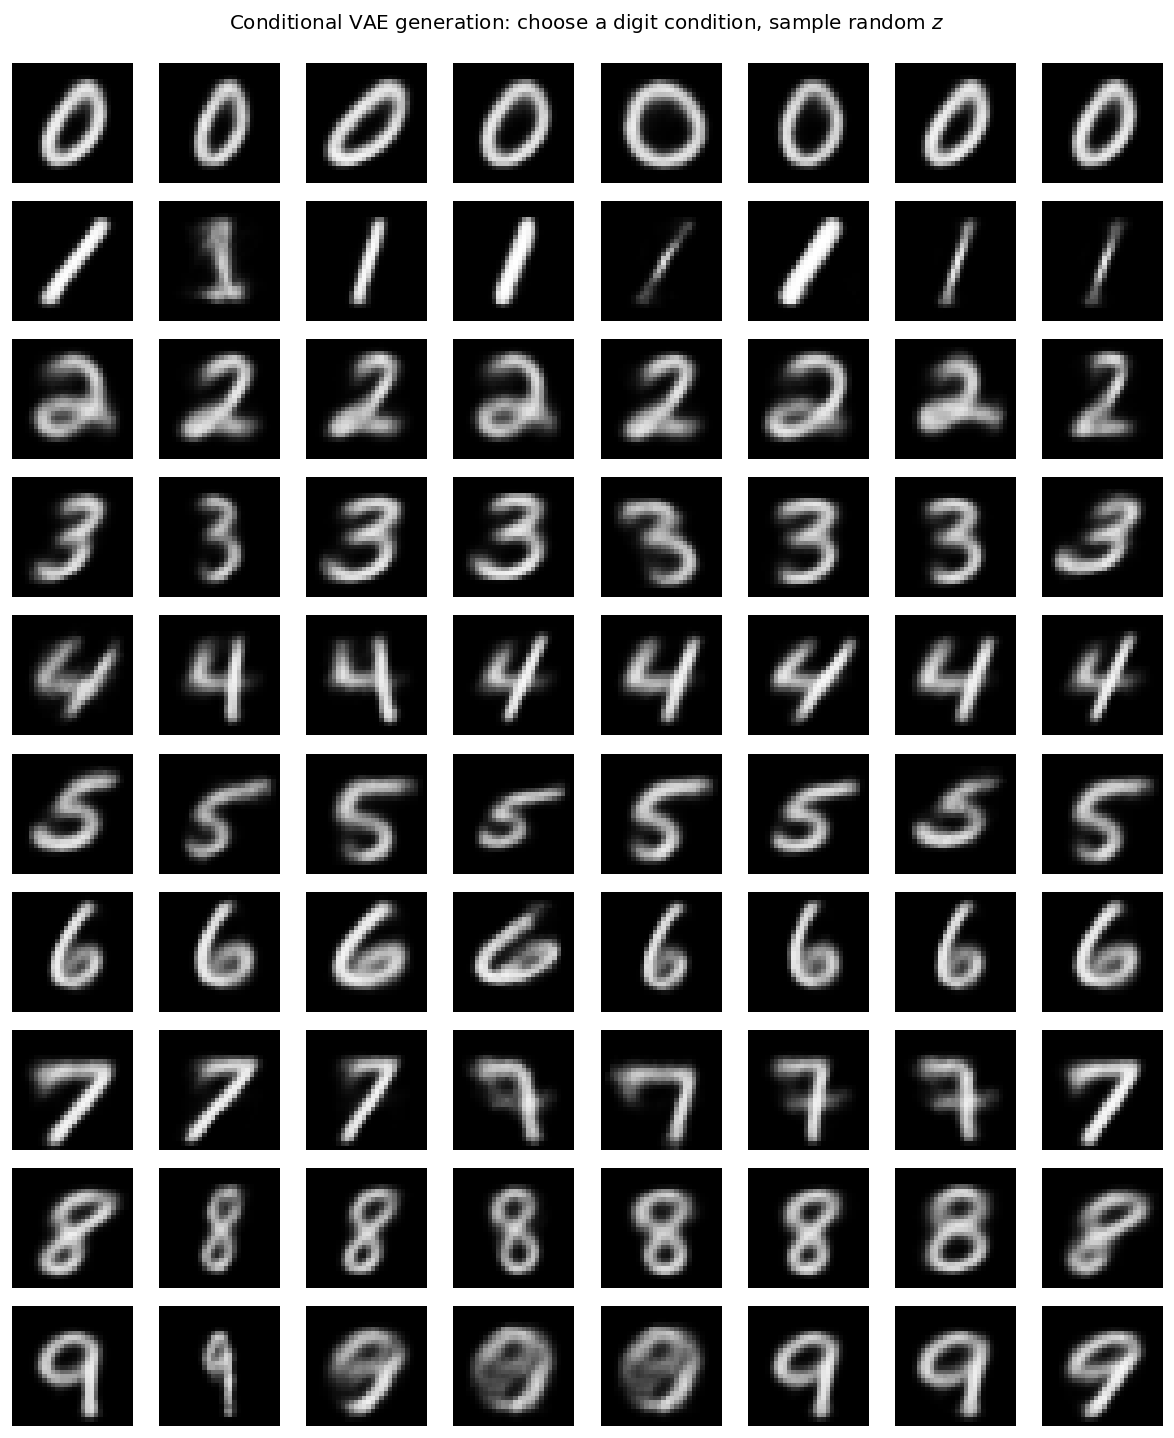

In [10]:
# ── 8.1 Conditional generation: choose c, sample z, decode ───────────────────

@torch.no_grad()
def generate_digits(
    model: ConditionalVAE,
    digit_label: int,
    n_samples: int,
    device: torch.device,
) -> torch.Tensor:
    """
    Generate n_samples MNIST digits for one requested condition.

    Parameters
    ----------
    model
        Trained ConditionalVAE.

    digit_label
        Requested digit condition in {0, ..., 9}.

    n_samples
        Number of new samples to generate.

    device
        Device used by the model.

    Returns
    -------
    generated_images
        Tensor with shape:
            (n_samples, 1, 28, 28)

        Pixel values are in [0, 1].
    """

    if not 0 <= digit_label <= 9:
        raise ValueError("digit_label must be an integer between 0 and 9.")

    model.eval()

    # Step 1: choose the requested condition.
    c_desired = torch.full(
        (n_samples,),
        fill_value=digit_label,
        dtype=torch.long,
        device=device,
    )

    # Step 2: sample random latent noise.
    z = torch.randn(
        n_samples,
        model.latent_dim,
        device=device,
    )

    # Step 3: decode (z, c_desired).
    x_logits = model.decode(z, c_desired)

    # Convert logits to pixel probabilities.
    generated_images = torch.sigmoid(x_logits)

    return generated_images.cpu()


# ── Generate several new examples of every digit ──────────────────────────────

N_SAMPLES_PER_DIGIT = 8

set_seed(SEED + 100)

fig, axes = plt.subplots(
    10,
    N_SAMPLES_PER_DIGIT,
    figsize=(10, 12),
)

for digit in range(10):

    generated_images = generate_digits(
        model=model,
        digit_label=digit,
        n_samples=N_SAMPLES_PER_DIGIT,
        device=DEVICE,
    )

    for j in range(N_SAMPLES_PER_DIGIT):

        axes[digit, j].imshow(
            generated_images[j].squeeze(0),
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[digit, j].axis("off")

    axes[digit, 0].set_ylabel(
        rf"$c_{{\mathrm{{desired}}}}={digit}$",
        rotation=0,
        labelpad=35,
        va="center",
        fontsize=11,
    )

fig.suptitle(
    "Conditional VAE generation: choose a digit condition, sample random $z$",
    y=0.995,
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "cvae_requested_digit_generation.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

# 8.2 Fix the condition, vary the latent vector

We now keep the condition fixed and only change the latent variable.

For example, we may choose:

$$
c_{\mathrm{desired}} = 7,
$$

and then sample many different latent vectors:

$$
z^{(1)}, z^{(2)}, \ldots, z^{(n)} \sim \mathcal{N}(0,I).
$$

Each generated sample is then:

$$
x^{(k)}_{\mathrm{new}}
=
\sigma\!\left(
g_\theta(z^{(k)}, c_{\mathrm{desired}})
\right).
$$

Because the condition is fixed, all generated samples should belong to the same digit class.

Because the latent vector changes, the generated samples can still vary in style, thickness, tilt, and shape.

This is the clearest demonstration that:

$$
c \text{ controls the digit identity,}
\qquad
z \text{ controls variation within that digit.}
$$

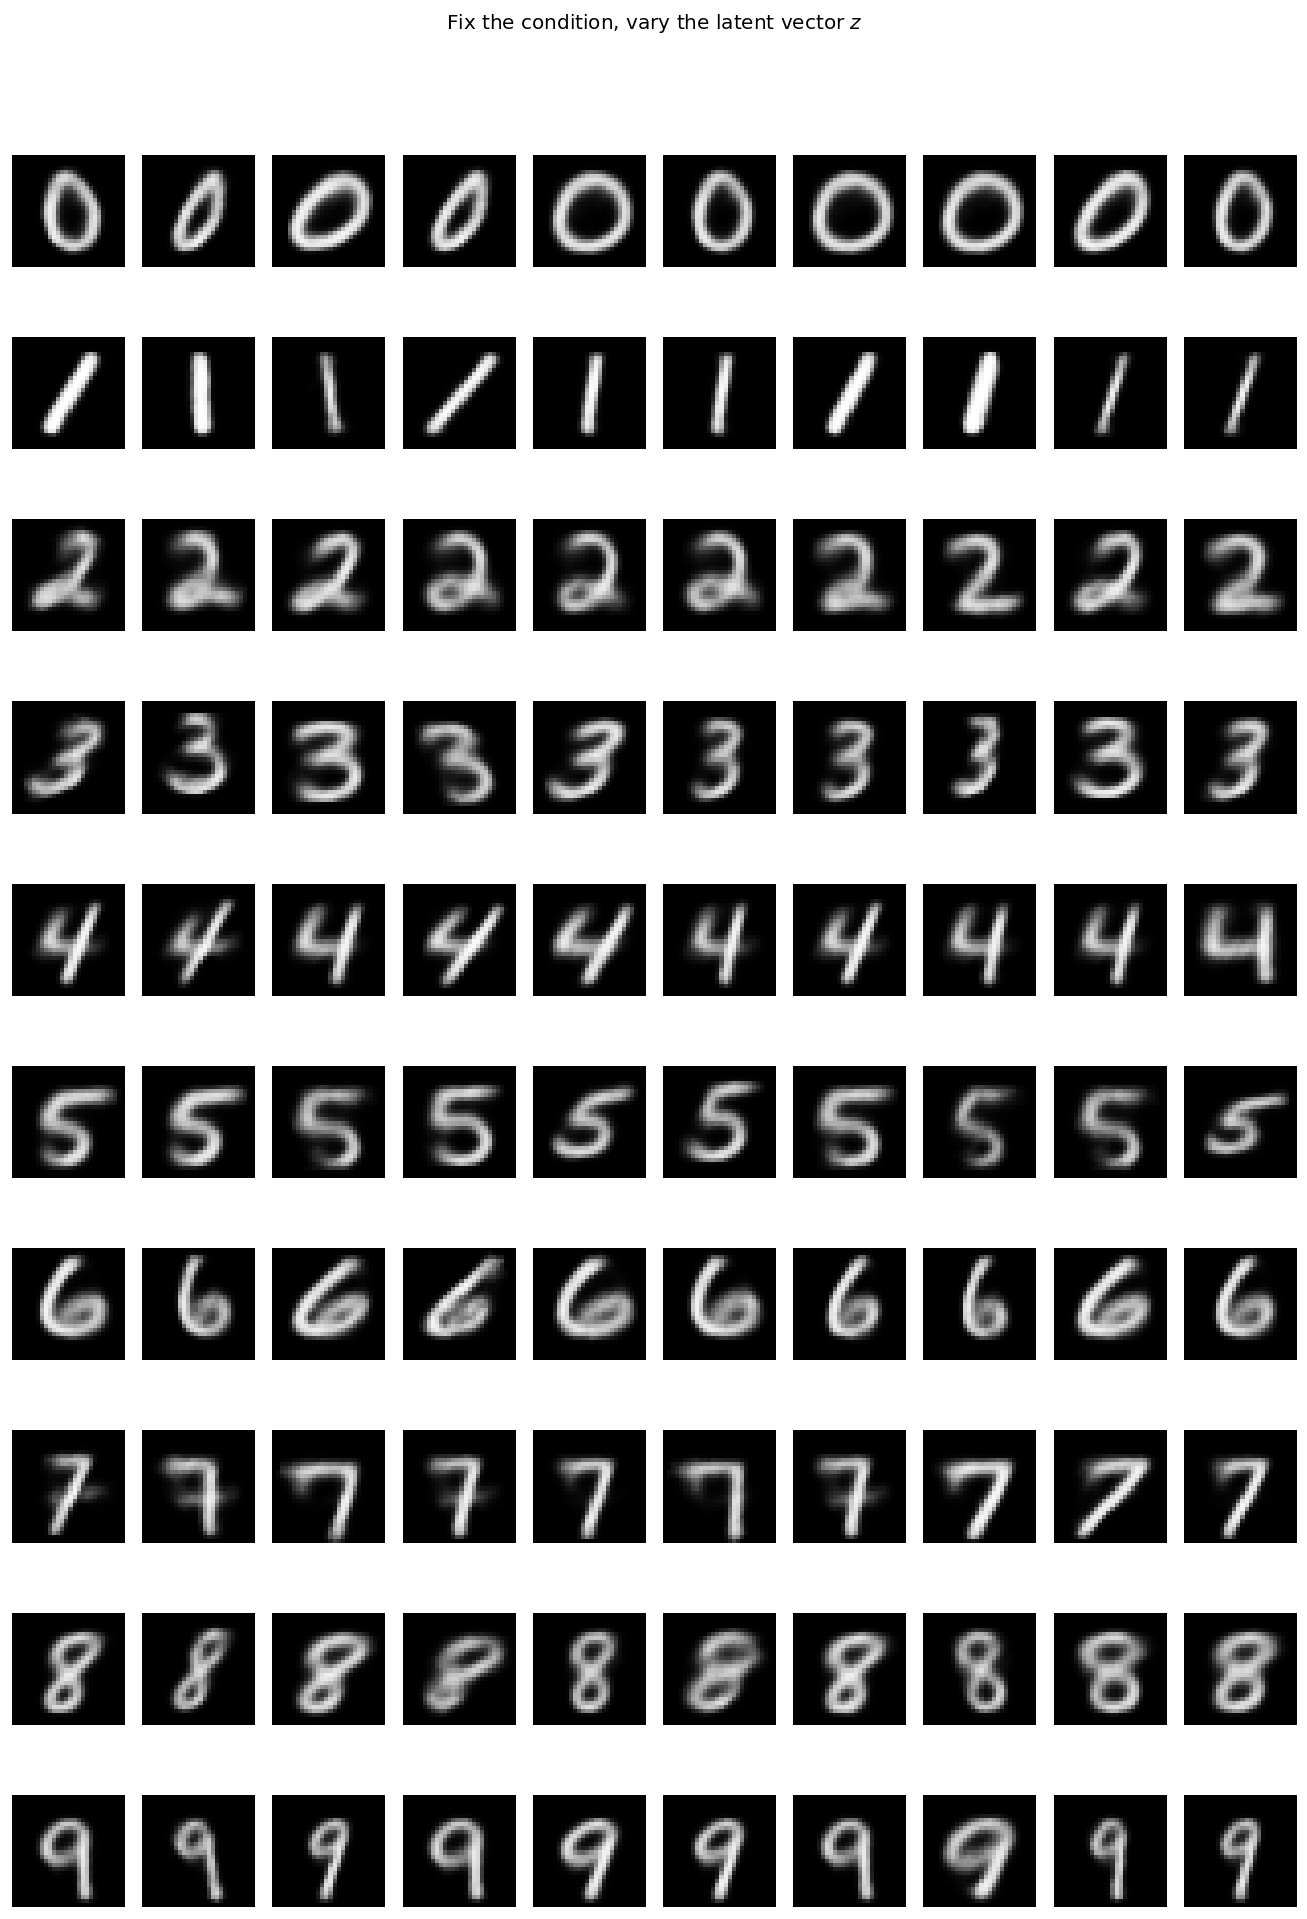

In [13]:
# ── 8.2 Fix c, vary z ─────────────────────────────────────────────────────────

@torch.no_grad()
def generate_with_fixed_condition(
    model: ConditionalVAE,
    digit_label: int,
    n_samples: int,
    device: torch.device,
) -> torch.Tensor:
    """
    Generate multiple samples for one fixed condition by varying z.

    Parameters
    ----------
    model
        Trained ConditionalVAE.

    digit_label
        Requested digit condition in {0, ..., 9}.

    n_samples
        Number of samples to generate.

    device
        Device used by the model.

    Returns
    -------
    generated_images
        Tensor of shape (n_samples, 1, 28, 28) with pixel values in [0, 1].
    """
    model.eval()

    c_fixed = torch.full(
        (n_samples,),
        fill_value=digit_label,
        dtype=torch.long,
        device=device,
    )

    z = torch.randn(
        n_samples,
        model.latent_dim,
        device=device,
    )

    x_logits = model.decode(z, c_fixed)
    x_generated = torch.sigmoid(x_logits)

    return x_generated.cpu()


# ── Visualize several fixed-condition generations ─────────────────────────────

DIGITS_TO_SHOW = [0, 1,2,3, 4,5,6, 7,8, 9]
N_SAMPLES_PER_DIGIT = 10

set_seed(SEED + 200)

fig, axes = plt.subplots(
    len(DIGITS_TO_SHOW),
    N_SAMPLES_PER_DIGIT,
    figsize=(11, 1.6 * len(DIGITS_TO_SHOW)),
)

for row, digit in enumerate(DIGITS_TO_SHOW):

    generated_images = generate_with_fixed_condition(
        model=model,
        digit_label=digit,
        n_samples=N_SAMPLES_PER_DIGIT,
        device=DEVICE,
    )

    for col in range(N_SAMPLES_PER_DIGIT):
        axes[row, col].imshow(
            generated_images[col].squeeze(0),
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[row, col].axis("off")

    axes[row, 0].set_ylabel(
        rf"$c={digit}$",
        rotation=0,
        labelpad=22,
        va="center",
        fontsize=11,
    )

fig.suptitle(
    "Fix the condition, vary the latent vector $z$",
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "cvae_fixed_c_vary_z.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()